<a href="https://colab.research.google.com/github/CanCengiz1/CanCengiz1/blob/main/lung_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Loading and Initial Inspection**

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

df = pd.read_csv("lung_disease_v1.csv")
df_raw = df.copy()
display(df.head())
print(df.shape)
df.info()


,patient_id,age,sex,bmi,smoking_status,pack_years,pm25_exposure,occupation,family_history,cough,...,dlco_pct_pred,cxr_finding,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hypertension,diabetes,hospital_visits_last_year,disease_type,severity
0,1,49,Male,20.1,Never,21.0,20.8,Office,NaN,1,...,82.1,Normal,3.0,11.9,447,1,1,0,Asthma,Moderate
1,2,61,Female,28.4,Current,34.1,10.8,Office,NaN,0,...,81.1,Normal,5.9,2.1,394,0,0,0,Lung Cancer,Mild/None
2,3,70,Male,22.2,Current,15.7,12.0,Manufacturing,NaN,1,...,85.4,Consolidation,2.8,4.8,309,0,1,0,Pneumonia,Mild/None
3,4,47,Male,23.1,Current,49.0,20.0,Manufacturing,NaN,0,...,49.0,Normal,1.8,29.4,190,0,0,0,COPD,Moderate
4,5,70,Female,29.0,Former,6.0,6.0,Office,NaN,0,...,81.6,Normal,1.0,9.5,314,0,0,0,Healthy,Mild/None


(12000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 12000 non-null  int64  
 1   age                        12000 non-null  int64  
 2   sex                        12000 non-null  object 
 3   bmi                        12000 non-null  float64
 4   smoking_status             12000 non-null  object 
 5   pack_years                 12000 non-null  float64
 6   pm25_exposure              12000 non-null  float64
 7   occupation                 12000 non-null  object 
 8   family_history             4824 non-null   object 
 9   cough                      12000 non-null  int64  
 10  dyspnea                    12000 non-null  int64  
 11  wheeze                     12000 non-null  int64  
 12  chest_pain                 12000 non-null  int64  
 13  fever                      12000 n

**EDA-1: Target**

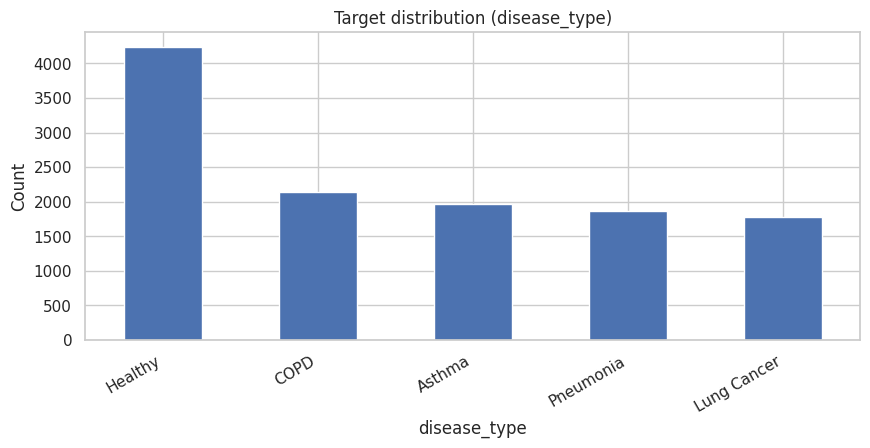

Target %:
disease_type
Healthy        35.36
COPD           17.89
Asthma         16.40
Pneumonia      15.51
Lung Cancer    14.84
Name: proportion, dtype: float64


In [ ]:
target_col = "disease_type"

plt.figure(figsize=(10,4))
df[target_col].value_counts().plot(kind="bar")
plt.title("Target distribution (disease_type)")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.show()

print("Target %:")
print((df[target_col].value_counts(normalize=True)*100).round(2))


**EDA-2: Missing values (family_history specifically)**

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values (top 15):")
print(missing.head(15))


Missing values (top 15):
family_history    7176
patient_id           0
age                  0
bmi                  0
sex                  0
smoking_status       0
pack_years           0
pm25_exposure        0
occupation           0
cough                0
dyspnea              0
wheeze               0
chest_pain           0
fever                0
hemoptysis           0
dtype: int64


**EDA-3: 2-3 histogram + 2-3 boxplot (according to target)**

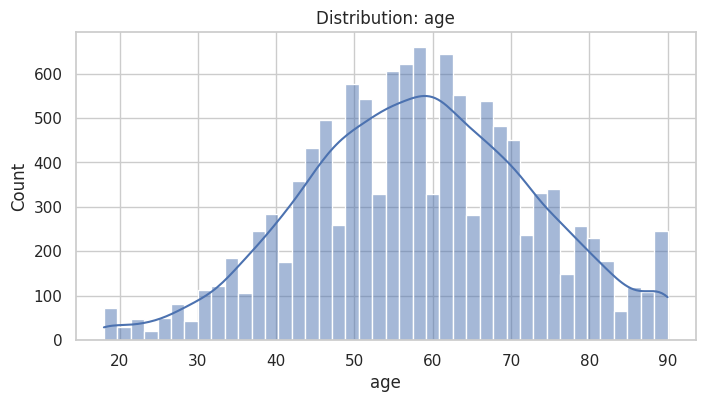

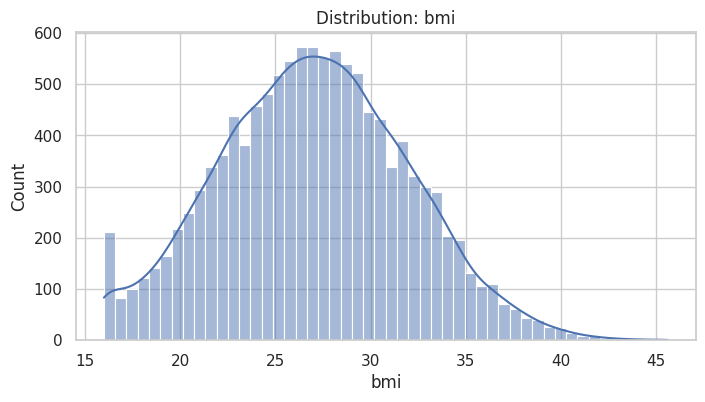

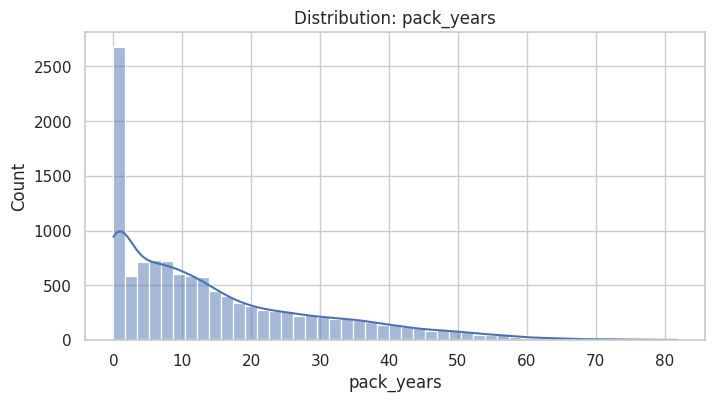

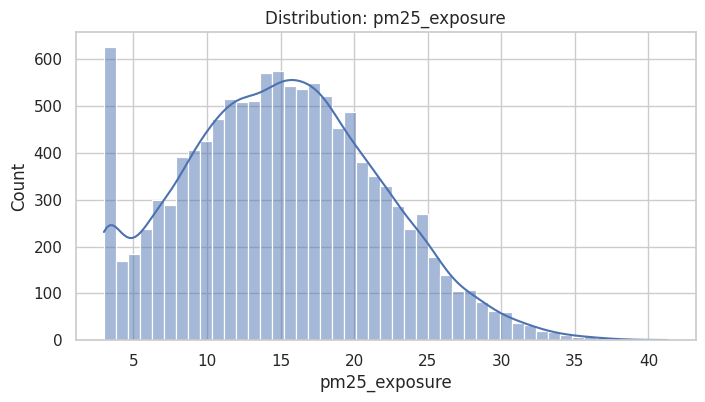

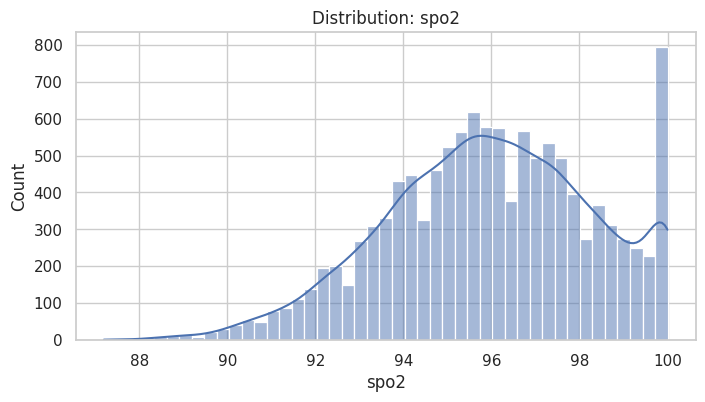

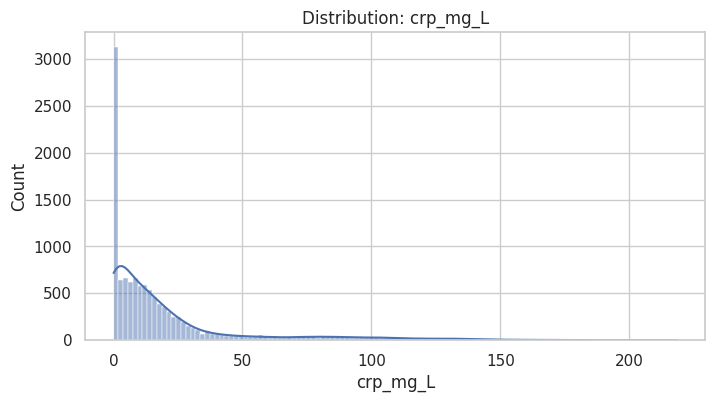

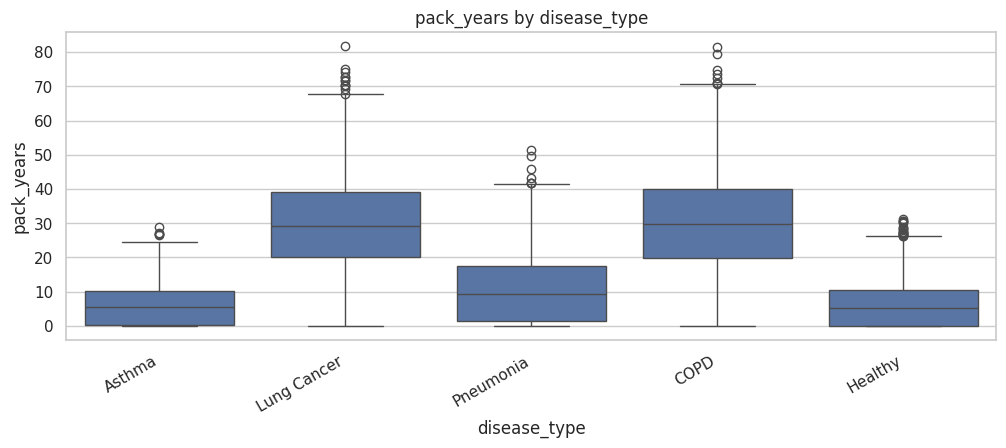

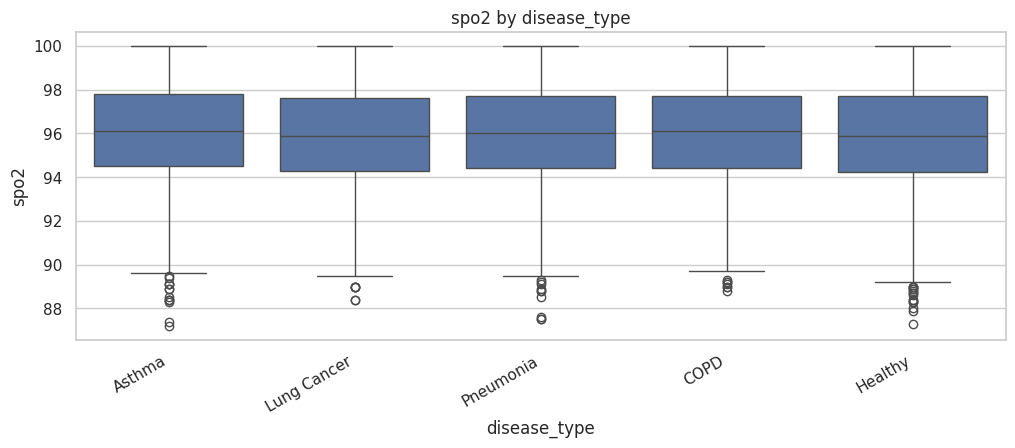

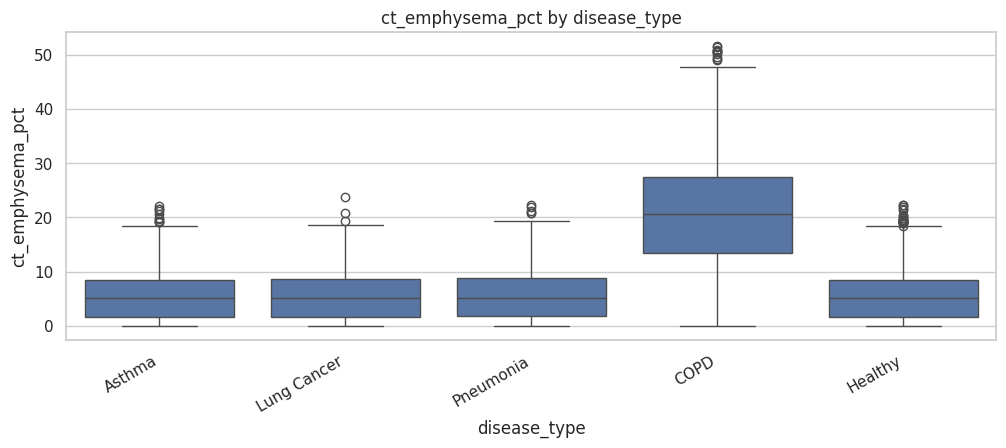

In [ ]:
# histogram
for col in ["age","bmi","pack_years","pm25_exposure","spo2","crp_mg_L"]:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution: {col}")
        plt.show()

# boxplot according to target
for col in ["pack_years","spo2","ct_emphysema_pct"]:
    if col in df.columns:
        plt.figure(figsize=(12,4))
        sns.boxplot(data=df, x=target_col, y=col)
        plt.title(f"{col} by {target_col}")
        plt.xticks(rotation=30, ha="right")
        plt.show()


**EDA-4: Correlation heatmap (numeric)**

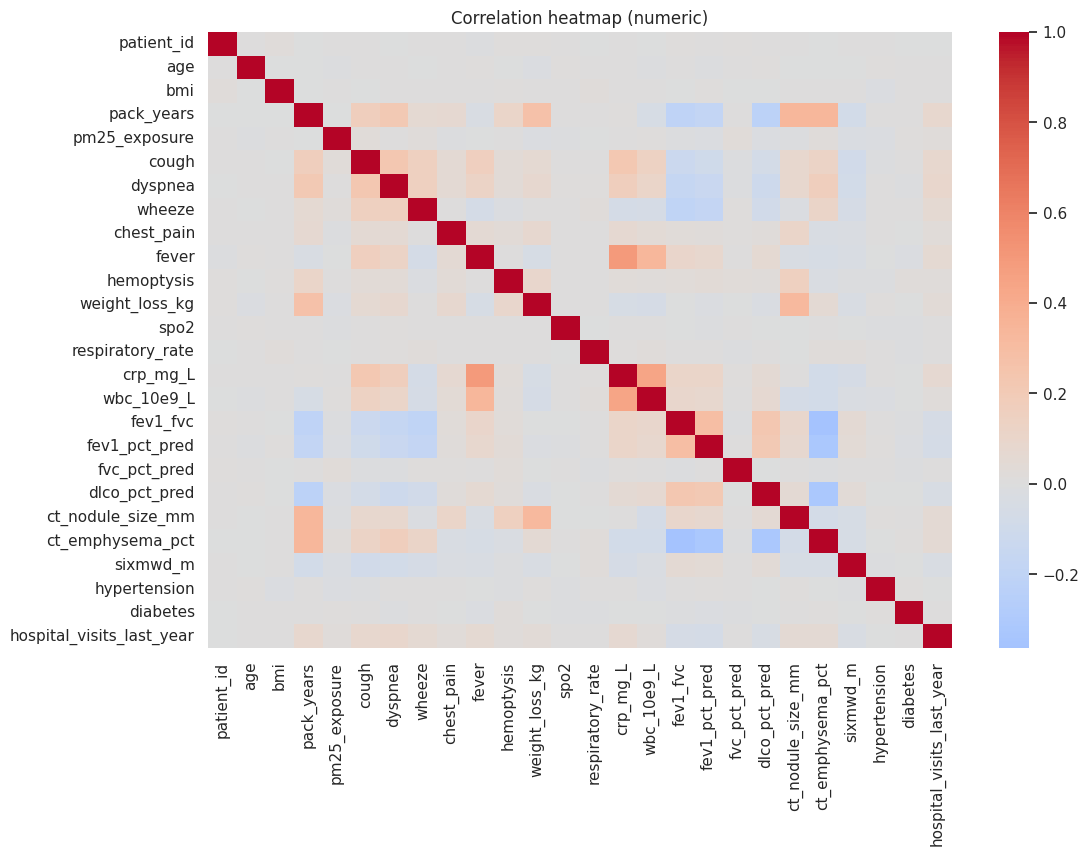

In [ ]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric)")
plt.show()


**EDA-5 Feature Relationship with Target Variable**

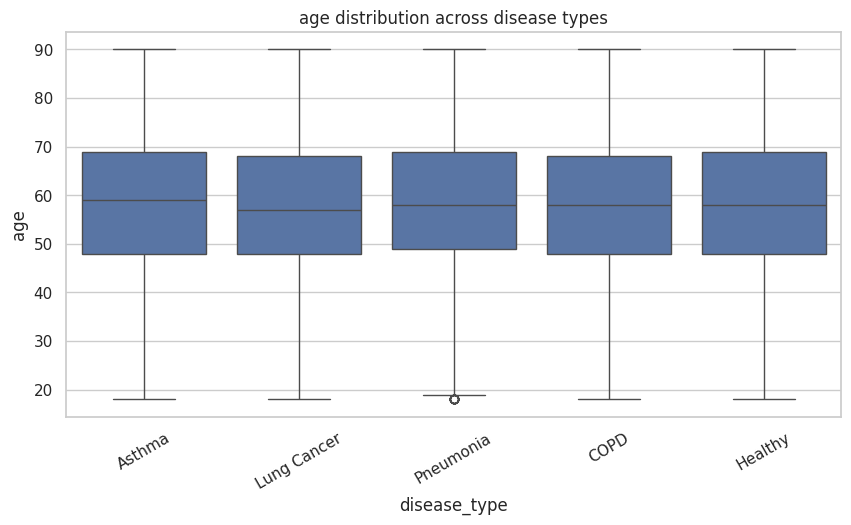

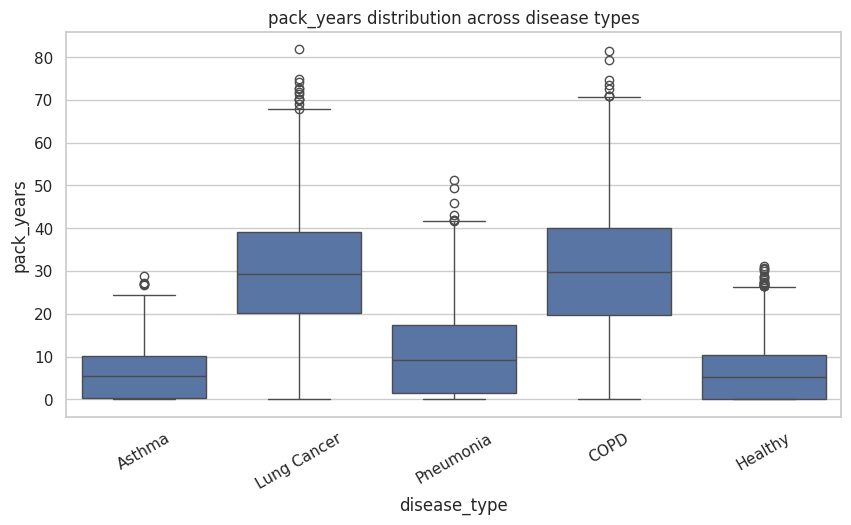

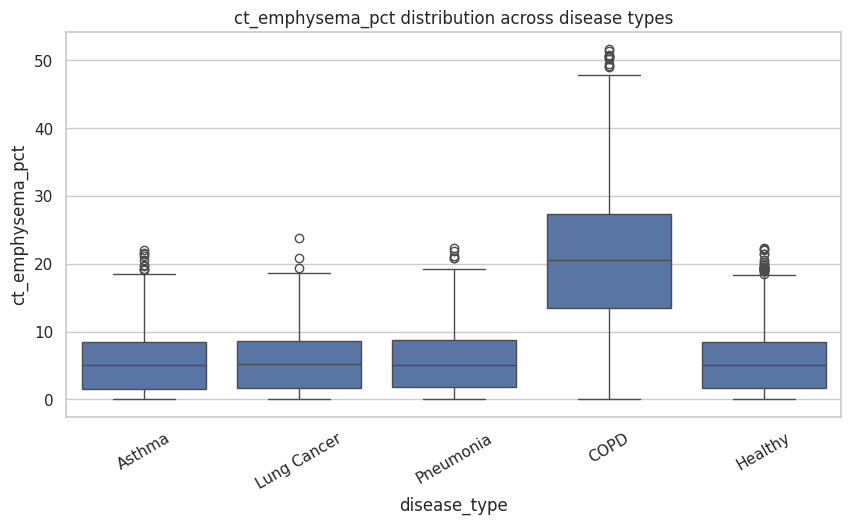

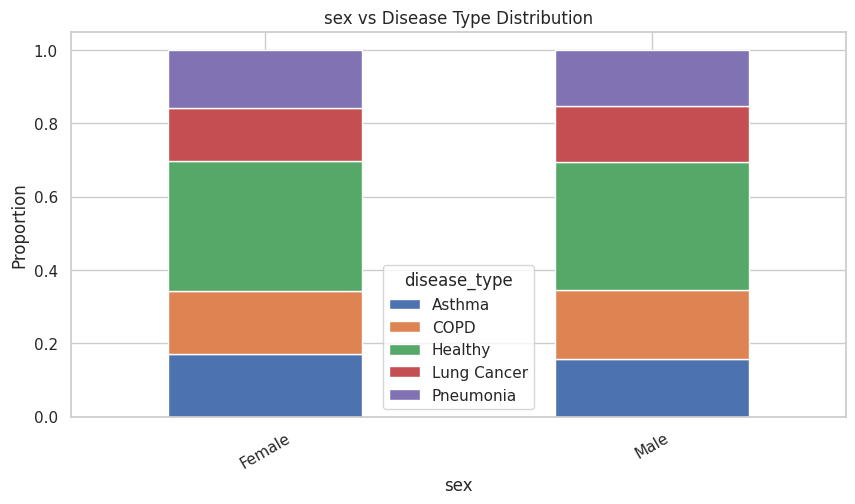

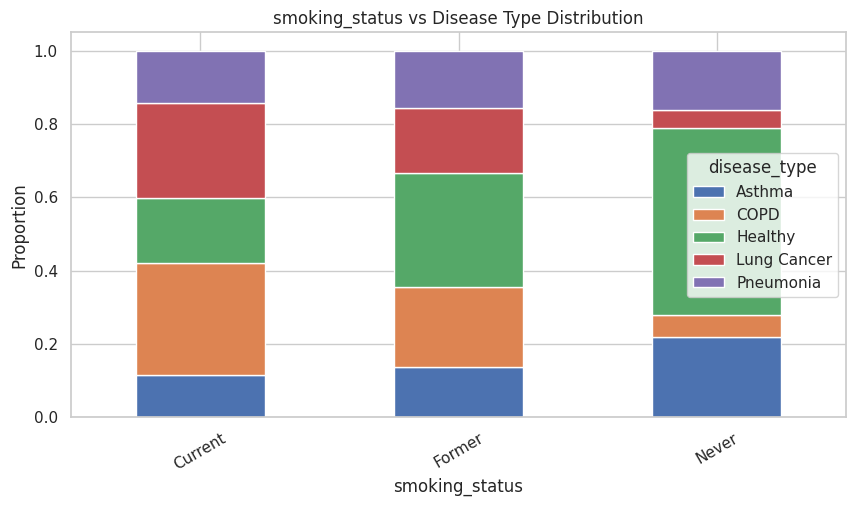

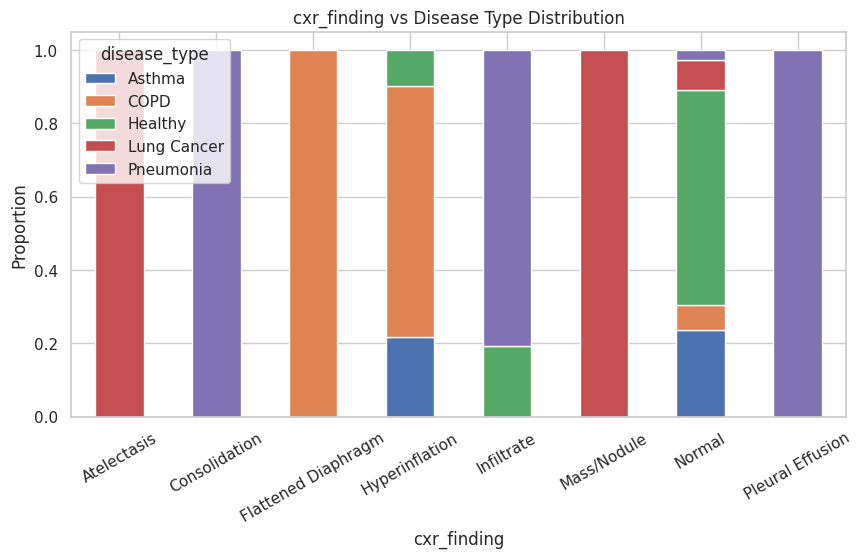

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Numeric feature relationship with target
num_cols_to_check = ["age", "pack_years", "spO2", "ct_emphysema_pct"]

for col in num_cols_to_check:
    if col in df.columns:
        plt.figure(figsize=(10,5))
        sns.boxplot(x="disease_type", y=col, data=df)
        plt.title(f"{col} distribution across disease types")
        plt.xticks(rotation=30)
        plt.show()


# Categorical feature relationship with target
cat_cols_to_check = ["sex", "smoking_status", "cxr_finding"]

for col in cat_cols_to_check:
    if col in df.columns:
        ct = pd.crosstab(df[col], df["disease_type"], normalize="index")
        ct.plot(kind="bar", stacked=True, figsize=(10,5))
        plt.title(f"{col} vs Disease Type Distribution")
        plt.ylabel("Proportion")
        plt.xticks(rotation=30)
        plt.show()


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,12000.0,6000.500000,3464.245950,1.00,3000.75,6000.50,9000.25,12000.00
age,12000.0,58.070833,14.741634,18.00,48.00,58.00,68.00,90.00
bmi,12000.0,27.008608,4.961936,16.00,23.50,27.00,30.40,45.60
pack_years,12000.0,14.767758,14.848183,0.00,2.70,10.30,22.80,81.80
pm25_exposure,12000.0,15.114308,6.689190,3.00,10.30,15.00,19.70,41.30
cough,12000.0,0.417333,0.493139,0.00,0.00,0.00,1.00,1.00
dyspnea,12000.0,0.397250,0.489349,0.00,0.00,0.00,1.00,1.00
wheeze,12000.0,0.246750,0.431138,0.00,0.00,0.00,0.00,1.00
chest_pain,12000.0,0.138083,0.345002,0.00,0.00,0.00,0.00,1.00
fever,12000.0,0.167000,0.372991,0.00,0.00,0.00,0.00,1.00


**Data Cleaning and Missing Value Handling**

In [ ]:

# Fill missing values in family_history column
df['family_history'] = df['family_history'].fillna('Unknown')

# BEFORE / AFTER validation
print("family_history missing BEFORE (raw df):", df_raw["family_history"].isna().sum())
print("family_history missing AFTER:", df["family_history"].isna().sum())

# Check distribution after filling missing values
print(df["family_history"].value_counts().head(5))

df.info()


family_history missing BEFORE (raw df): 7176
family_history missing AFTER: 0
family_history
Unknown    7176
COPD       1845
Asthma     1791
Cancer     1188
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 12000 non-null  int64  
 1   age                        12000 non-null  int64  
 2   sex                        12000 non-null  object 
 3   bmi                        12000 non-null  float64
 4   smoking_status             12000 non-null  object 
 5   pack_years                 12000 non-null  float64
 6   pm25_exposure              12000 non-null  float64
 7   occupation                 12000 non-null  object 
 8   family_history             12000 non-null  object 
 9   cough                      12000 non-null  int64  
 10  dyspnea                    12000

**Splitting Dataset into Input Features (X) and Target Variable (y)**

In [ ]:

X = df.drop('disease_type', axis=1)
y = df['disease_type']

print(X.shape, y.shape)

(12000, 32) (12000,)


**Identifying Numerical and Categorical Features**

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric:", len(numeric_features), numeric_features.tolist())
print("Categorical:", len(categorical_features), categorical_features.tolist())


Numeric: 26 ['patient_id', 'age', 'bmi', 'pack_years', 'pm25_exposure', 'cough', 'dyspnea', 'wheeze', 'chest_pain', 'fever', 'hemoptysis', 'weight_loss_kg', 'spo2', 'respiratory_rate', 'crp_mg_L', 'wbc_10e9_L', 'fev1_fvc', 'fev1_pct_pred', 'fvc_pct_pred', 'dlco_pct_pred', 'ct_nodule_size_mm', 'ct_emphysema_pct', 'sixmwd_m', 'hypertension', 'diabetes', 'hospital_visits_last_year']
Categorical: 6 ['sex', 'smoking_status', 'occupation', 'family_history', 'cxr_finding', 'severity']


**Data Preprocessing and Pipeline Construction**

In [ ]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Numerical and categorical feature lists obtained from previous step

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Creating preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Training Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['patient_id', 'age', 'bmi', 'pack_years', 'pm25_exposure', 'cough',
       'dyspnea', 'wheeze', 'chest_pain', 'fever', 'hemoptysis',
       'weight_loss_kg', 'spo2', 'respiratory_rate', 'crp_mg_L', 'wbc_10e9_L'...
       'ct_nodule_size_mm', 'ct_emphysema_pct', 'sixmwd_m', 'hypertension',
       'diabetes', 'hospital_visits_last_year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'smoking_status', 'occupation', 'family_history', 'cxr_finding',
       'severity'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=500))])

**Logistic Regression Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9416666666666667

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

      Asthma       0.88      0.81      0.85       394
        COPD       0.98      0.96      0.97       429
     Healthy       0.91      0.96      0.94       849
 Lung Cancer       0.99      0.97      0.98       356
   Pneumonia       0.98      0.99      0.98       372

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.94      0.94      0.94      2400



**Confusion Matrix**

<Figure size 1000x800 with 0 Axes>

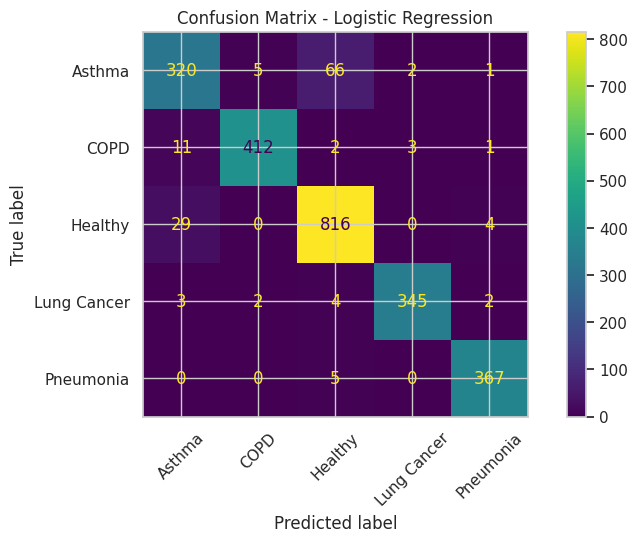

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=log_reg.named_steps["classifier"].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.named_steps["classifier"].classes_)

plt.figure(figsize=(10,8))
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


**Defining Additional Machine Learning Models**

In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])


**Recording Initial Model Hyperparameters**

In [ ]:
for name, model in models.items():
    print(f"\n{name} initial parameters:")
    print(model.get_params())


Logistic Regression initial parameters:
{'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['patient_id', 'age', 'bmi', 'pack_years', 'pm25_exposure', 'cough',
       'dyspnea', 'wheeze', 'chest_pain', 'fever', 'hemoptysis',
       'weight_loss_kg', 'spo2', 'respiratory_rate', 'crp_mg_L', 'wbc_10e9_L',
       'fev1_fvc', 'fev1_pct_pred', 'fvc...
       'ct_nodule_size_mm', 'ct_emphysema_pct', 'sixmwd_m', 'hypertension',
       'diabetes', 'hospital_visits_last_year'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
          

**Training and Comparing Machine Learning Models**

In [ ]:
models = {
    "Logistic Regression": log_reg,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = m.score(X_test, y_test)
    print(f"{name}: {acc:.4f}")


Logistic Regression: 0.9417
SVM: 0.9375
Decision Tree: 0.8925
Random Forest: 0.9425
KNN: 0.8642


**Model Performance Comparison**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.942500,0.942627,0.942500,0.941752
0,Logistic Regression,0.941667,0.941639,0.941667,0.941171
1,SVM,0.937500,0.938066,0.937500,0.937068
2,Decision Tree,0.892500,0.894066,0.892500,0.893137
4,KNN,0.864167,0.874747,0.864167,0.863944


**Comparative Model Performance Table**

In [ ]:
# Comparative Model Performance Table

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

rows = []

for name, m in models.items():
    m.fit(X_train, y_train)
    yhat = m.predict(X_test)

    acc = accuracy_score(y_test, yhat)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, yhat, average="weighted"
    )

    rows.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(
    rows,
    columns=["Model", "Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"]
)

results_df = results_df.sort_values("Accuracy", ascending=False)

display(results_df)


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
3,Random Forest,0.942500,0.942627,0.942500,0.941752
0,Logistic Regression,0.941667,0.941639,0.941667,0.941171
1,SVM,0.937500,0.938066,0.937500,0.937068
2,Decision Tree,0.892500,0.894066,0.892500,0.893137
4,KNN,0.864167,0.874747,0.864167,0.863944


**Best model (Confusion Matrix)**

Logistic Regression: 0.9417
SVM: 0.9375
Decision Tree: 0.8925
Random Forest: 0.9425
KNN: 0.8642

Best model: Random Forest
Best accuracy: 0.9425


<Figure size 1000x800 with 0 Axes>

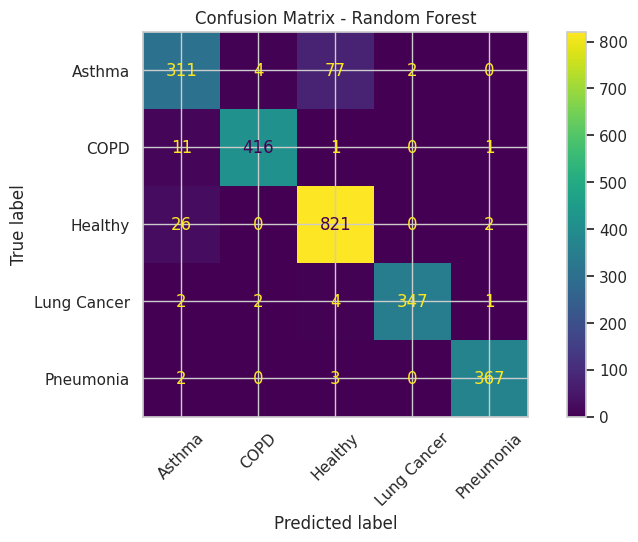

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

scores = {}
fitted = {}

# train models and calculate accuracy
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    scores[name] = acc
    fitted[name] = m

    print(f"{name}: {acc:.4f}")

# Best model
best_name = max(scores, key=scores.get)
best_model = fitted[best_name]

print("\nBest model:", best_name)
print("Best accuracy:", scores[best_name])

# best model confusion matrix
y_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_best,
    labels=best_model.named_steps["classifier"].classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.named_steps["classifier"].classes_
)

plt.figure(figsize=(10,8))
disp.plot(xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


**ROC Curves (One-vs-Rest) – Tuned Random Forest**

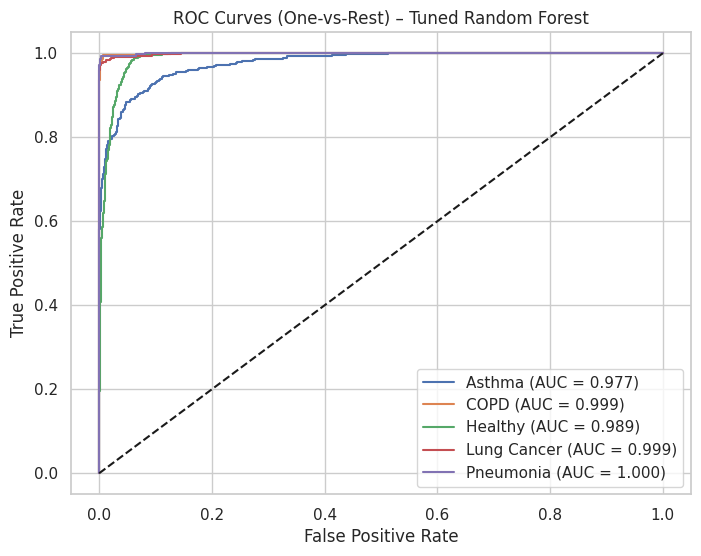

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

model_for_roc = tuned_rf  # tuned random forest pipeline

classes = model_for_roc.named_steps["classifier"].classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model_for_roc.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) – Tuned Random Forest")
plt.legend()
plt.show()


*The ROC curves show that the tuned Random Forest model achieves strong class discrimination across all disease categories, with AUC values close to 1.0. This indicates that the model maintains high sensitivity and specificity for multi-class disease prediction.*


**Hypermeter Tunning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_dist = {
    "classifier__n_estimators": [200, 400, 600],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV macro-F1:", search.best_score_)

tuned_rf = search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'classifier__n_estimators': 600, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}
Best CV macro-F1: 0.9452611139138671


**Model Performance Improvement (Before vs After Tuning)**

Base RF Accuracy: 0.9425
Tuned RF Accuracy: 0.9441666666666667
Base macro F1: 0.9438700259817457
Tuned macro F1: 0.9449737272205084

Base RF Classification Report:
               precision    recall  f1-score   support

      Asthma       0.88      0.79      0.83       394
        COPD       0.99      0.97      0.98       429
     Healthy       0.91      0.97      0.94       849
 Lung Cancer       0.99      0.97      0.98       356
   Pneumonia       0.99      0.99      0.99       372

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.94      0.94      0.94      2400


Tuned RF Classification Report:
               precision    recall  f1-score   support

      Asthma       0.91      0.78      0.84       394
        COPD       0.99      0.97      0.98       429
     Healthy       0.90      0.98      0.94       849
 Lung Cancer       0.99      0.97      0.98       356
   Pneumonia       0.99      0.98      0.

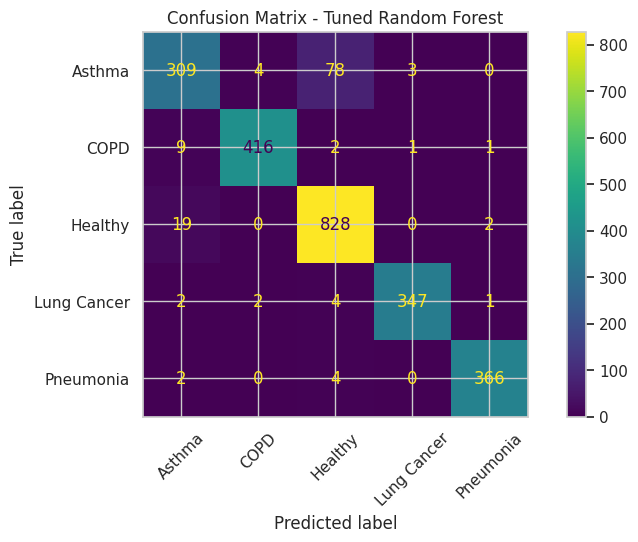

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Base RF
base_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

base_rf.fit(X_train, y_train)

y_base = base_rf.predict(X_test)
y_tuned = tuned_rf.predict(X_test)

print("Base RF Accuracy:", accuracy_score(y_test, y_base))
print("Tuned RF Accuracy:", accuracy_score(y_test, y_tuned))

print("Base macro F1:", f1_score(y_test, y_base, average="macro"))
print("Tuned macro F1:", f1_score(y_test, y_tuned, average="macro"))

print("\nBase RF Classification Report:\n", classification_report(y_test, y_base))
print("\nTuned RF Classification Report:\n", classification_report(y_test, y_tuned))

#  Tuned model confusion matrix
cm = confusion_matrix(y_test, y_tuned, labels=tuned_rf.named_steps["classifier"].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tuned_rf.named_steps["classifier"].classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

**Preparing Feature Names for Feature Importance Analysis**

In [ ]:
import numpy as np
import pandas as pd

def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    # Numeric names
    num_names = np.array(numeric_features)

    # get Categorical transformer pipeline
    cat_pipe = preprocessor.named_transformers_["cat"]

    # if OneHot :
    if hasattr(cat_pipe, "named_steps") and "onehot" in cat_pipe.named_steps:
        ohe = cat_pipe.named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_features)

    # If it is ordinal: each column remains as a single column → column names are sufficient.
    elif hasattr(cat_pipe, "named_steps") and "ordinal" in cat_pipe.named_steps:
        cat_names = np.array(categorical_features)

    #  fallback for other conditions
    else:
        cat_names = np.array(categorical_features)

    return np.concatenate([num_names, cat_names])

# tuned_rf tuning
prep_used = tuned_rf.named_steps["preprocessor"]

feature_names = get_feature_names_from_preprocessor(
    prep_used,
    numeric_features,
    categorical_features
)

print("Feature names length:", len(feature_names))

# for security: check the number of transformed feature
Xt = tuned_rf.named_steps["preprocessor"].transform(X_test)
print("Transformed X_test shape:", Xt.shape)


Feature names length: 53
Transformed X_test shape: (2400, 53)


**Permutation Importance + Graph**

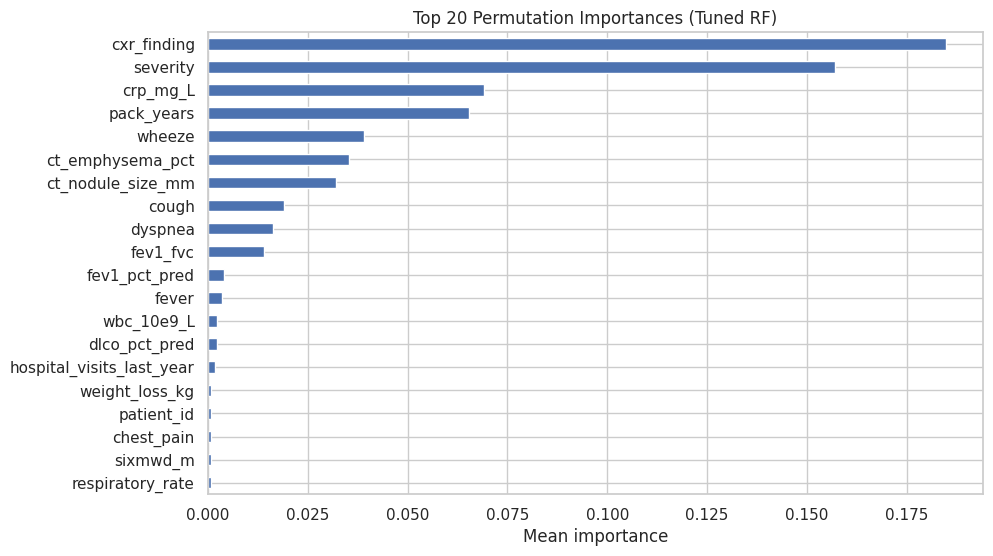

,0
cxr_finding,0.184917
severity,0.157000
crp_mg_L,0.069250
pack_years,0.065417
wheeze,0.039000
ct_emphysema_pct,0.035250
ct_nodule_size_mm,0.032167
cough,0.019083
dyspnea,0.016167
fev1_fvc,0.013917


In [ ]:
# Permutation Importance (Raw Feature Level)

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    tuned_rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Permutation Importances (Tuned RF)")
plt.xlabel("Mean importance")
plt.show()

display(importances.head(20))
